# [Lab 5-4] Denoising Diffusion Probabilistic Model (DDPM) 기초 실습

본 실습에서는 최근 생성형 AI(Generative AI) 분야를 이끌고 있는 핵심 아키텍처인 **확산 모델(Diffusion Model, DDPM)**의 수학적 원리와 생성 과정을 이해하고, MNIST 손글씨 데이터를 생성하는 모델을 밑바닥부터 구현합니다.

---

### 🌟 왜 지금 Diffusion Model인가?
| 생성 모델 | 장점 | 한계점 |
|---|---|---|
| **VAE** | 안정적인 훈련, 확률적 잠재 공간 | 픽셀 평균으로 인한 **흐릿한(Blurry) 결과물** |
| **GAN** | 매우 선명한 고화질 생성 | 판별자와 생성자의 적대적 균형 유지 어려움, **Mode Collapse(다양성 붕괴), 훈련 불안정** |
| **Diffusion** | **극도로 안정적인 훈련(MSE 손실)**, **압도적인 고화질과 다양성** | 다단계 반복 샘플링으로 인한 **느린 생성 속도** |

---

### 📐 DDPM의 핵심 2단계 프로세스
1. **순방향 확산 과정 (Forward Diffusion Process, $q$)**:
   - 원본 깨끗한 이미지 $x_0$에 사전에 정해진 스케줄($\beta_1, \dots, \beta_T$)에 따라 단계별로 미세한 가우시안 노이즈를 주입하여, $T$ 시점에서는 **완전한 무작위 가우시안 노이즈 $x_T \sim \mathcal{N}(0, I)$**로 붕괴시키는 과정입니다. (별도의 학습 불필요)
   - **Closed-form 수식**:
     $$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$
     (여기서 $\alpha_t = 1 - \beta_t, \;\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$)
2. **역방향 복원 과정 (Reverse Denoising Process, $p_\theta$)**:
   - 순수 노이즈 $x_T$로부터 시작하여 한 스텝씩 노이즈를 걷어내며 원본 이미지를 복원해 나가는 생성 과정입니다.
   - 신경망(U-Net)은 **"주어진 노이즈 이미지 $x_t$와 시간 $t$로부터 주입되었던 노이즈 $\epsilon$을 예측"**하도록 학습됩니다:
     $$\text{Loss} = \mathbb{E}_{t, x_0, \epsilon} \left[ \|\epsilon - \epsilon_\theta(x_t, t)\|^2 \right]$$

In [1]:
# 필수 라이브러리 임포트 및 시각화 설정
import math
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   # GPU 사용 안함

import tensorflow as tf
from tensorflow.keras import layers, models

# 한글 폰트 및 마이너스 부호 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"TensorFlow 버전: {tf.__version__}")
print(f"NumPy 버전: {np.__version__}")

TensorFlow 버전: 2.10.1
NumPy 버전: 1.26.4


## 1. 데이터 준비 및 노이즈 스케줄러 (Noise Scheduler) 구현

### 1.1 MNIST 데이터 로드 및 정규화
확산 모델에서는 픽셀 범위를 주로 $[-1, 1]$로 정규화하여 가우시안 노이즈 $\mathcal{N}(0, 1)$와의 스케일을 맞춥니다.

In [2]:
# MNIST 데이터 로드
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# [-1, 1] 범위로 정규화 (Diffusion 표준)
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_test = (x_test.astype("float32") - 127.5) / 127.5

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"훈련 데이터 형태: {x_train.shape}, 값 범위: [{x_train.min():.1f}, {x_train.max():.1f}]")

훈련 데이터 형태: (60000, 28, 28, 1), 값 범위: [-1.0, 1.0]


### 1.2 선형 노이즈 스케줄러 (Linear Noise Schedule) 정의
- 총 타임스텝 수: $T = 200$ (실습 효율을 위해 200 스텝 설정)
- $\beta_1 = 0.0001 \to \beta_T = 0.02$ 선형 증가
- $\alpha_t = 1 - \beta_t$
- $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$ (누적 곱)

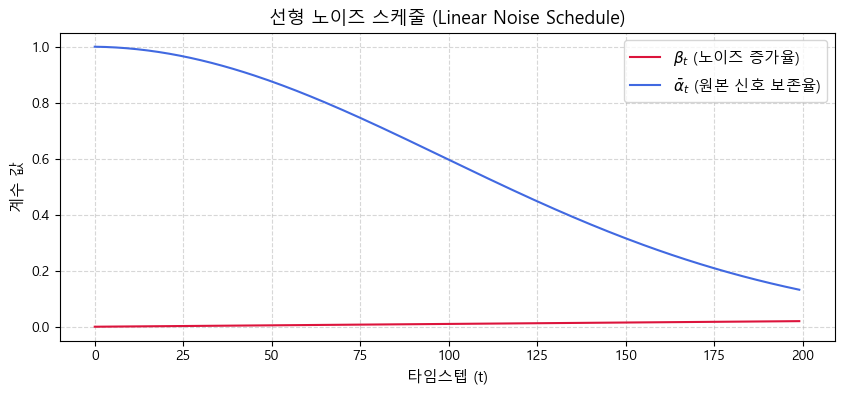

In [3]:
# 노이즈 스케줄러 매개변수 설정
timesteps = 200

# 1. beta 스케줄 (선형 증가)
beta = np.linspace(0.0001, 0.02, timesteps, dtype=np.float32)

# 2. alpha 및 누적 alpha 계산
alpha = 1.0 - beta
alpha_bar = np.cumprod(alpha)

# TensorFlow 상수 텐서로 변환
beta_tf = tf.constant(beta, dtype=tf.float32)
alpha_tf = tf.constant(alpha, dtype=tf.float32)
alpha_bar_tf = tf.constant(alpha_bar, dtype=tf.float32)
sqrt_alpha_bar_tf = tf.sqrt(alpha_bar_tf)
sqrt_one_minus_alpha_bar_tf = tf.sqrt(1.0 - alpha_bar_tf)

# 스케줄 시각화
plt.figure(figsize=(10, 4))
plt.plot(beta, label=r"$\beta_t$ (노이즈 증가율)", color='crimson')
plt.plot(alpha_bar, label=r"$\bar{\alpha}_t$ (원본 신호 보존율)", color='royalblue')
plt.xlabel("타임스텝 (t)", fontsize=11)
plt.ylabel("계수 값", fontsize=11)
plt.title("선형 노이즈 스케줄 (Linear Noise Schedule)", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 2. 순방향 확산 과정 (Forward Diffusion Process) 시각화

임의의 타임스텝 $t$에서의 노이즈 낀 이미지 $x_t$는 이전 스텝들을 거치지 않고 **단 한 번의 수식**으로 즉시 샘플링할 수 있습니다:
$$x_t = \sqrt{\bar{\alpha}_t} \, x_0 + \sqrt{1 - \bar{\alpha}_t} \, \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

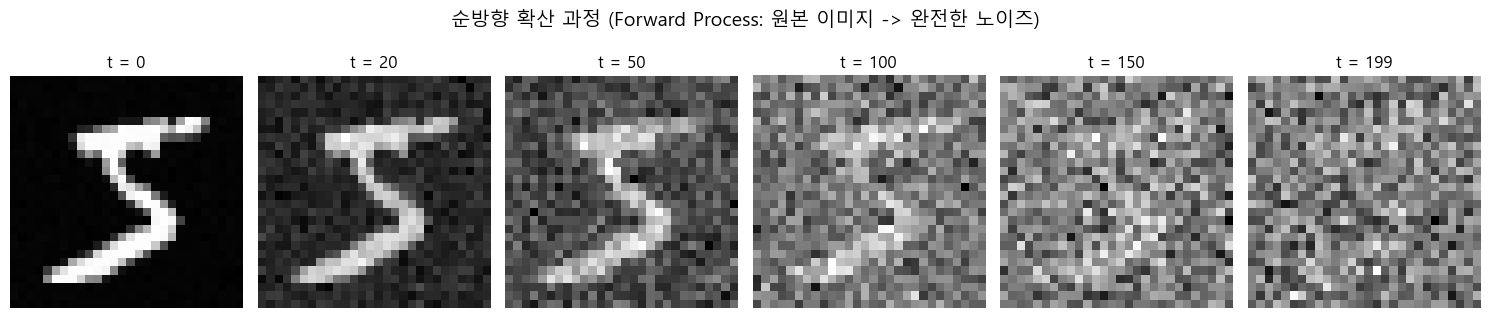

In [4]:
def q_sample(x_start, t, noise=None):
    # 임의의 타임스텝 t에서의 noised 이미지 x_t 생성
    if noise is None:
        noise = tf.random.normal(shape=tf.shape(x_start))
    
    # 배치 인덱스에 맞는 sqrt_alpha_bar 추출
    sqrt_alpha_bar_t = tf.gather(sqrt_alpha_bar_tf, t)
    sqrt_alpha_bar_t = tf.reshape(sqrt_alpha_bar_t, [-1, 1, 1, 1])
    
    sqrt_one_minus_alpha_bar_t = tf.gather(sqrt_one_minus_alpha_bar_tf, t)
    sqrt_one_minus_alpha_bar_t = tf.reshape(sqrt_one_minus_alpha_bar_t, [-1, 1, 1, 1])
    
    return sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise

# 원본 샘플 1개에 대해 단계별 노이즈 주입 시각화
sample_img = tf.constant(x_train[0:1])
steps_to_show = [0, 20, 50, 100, 150, 199]

plt.figure(figsize=(15, 3))
for i, t_val in enumerate(steps_to_show):
    t_tensor = tf.constant([t_val])
    noisy_img = q_sample(sample_img, t_tensor)
    
    ax = plt.subplot(1, len(steps_to_show), i + 1)
    # [-1, 1] -> [0, 1] 복원하여 시각화
    plt.imshow((noisy_img[0].numpy().squeeze() + 1.0) / 2.0, cmap="gray")
    plt.title(f"t = {t_val}", fontsize=12)
    plt.axis("off")

plt.suptitle("순방향 확산 과정 (Forward Process: 원본 이미지 -> 완전한 노이즈)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 3. 노이즈 예측 네트워크 (Lightweight U-Net) 구축

신경망은 $x_t$와 시간 $t$를 입력받아, 주입된 노이즈 $\epsilon$을 예측합니다.
- **시간 임베딩 (Sinusoidal Time Embedding)**: 트랜스포머의 Positional Encoding과 유사하게 스칼라 타임스텝 $t$를 고차원 임베딩 벡터로 변환하여 신경망이 현재 노이즈 강도를 인지할 수 있도록 합니다.
- **U-Net 구조**: Down-sampling 계층과 Up-sampling 계층을 거치며 Skip Connection을 통해 미세한 공간 디테일을 보존합니다.

In [5]:
def get_sinusoidal_time_embedding(timesteps, embedding_dim=32):
    # 시간 스텝 t를 위한 사인-코사인 시간 임베딩
    half_dim = embedding_dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = tf.exp(tf.range(half_dim, dtype=tf.float32) * -emb)
    emb = tf.cast(timesteps, dtype=tf.float32)[:, None] * emb[None, :]
    emb = tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)
    return emb

def build_mini_unet(image_size=28, channels=1, time_dim=32):
    # 경량화된 U-Net 아키텍처
    # 입력 1: 노이즈 이미지 x_t (28, 28, 1)
    image_input = layers.Input(shape=(image_size, image_size, channels), name="image_input")
    # 입력 2: 시간 스텝 t (스칼라 정수)
    time_input = layers.Input(shape=(), dtype=tf.int32, name="time_input")

    # 시간 임베딩 생성 (B, time_dim)
    t_emb = layers.Lambda(lambda t: get_sinusoidal_time_embedding(t, time_dim))(time_input)
    t_emb = layers.Dense(64, activation="swish")(t_emb)
    t_emb = layers.Dense(64)(t_emb)

    # --- Down-sampling (인코더) ---
    c1 = layers.Conv2D(32, 3, padding="same", activation="relu")(image_input)
    c1 = layers.Conv2D(32, 3, padding="same", activation="relu")(c1)
    p1 = layers.MaxPooling2D(2)(c1)  # 14x14

    c2 = layers.Conv2D(64, 3, padding="same", activation="relu")(p1)
    c2 = layers.Conv2D(64, 3, padding="same", activation="relu")(c2)
    p2 = layers.MaxPooling2D(2)(c2)  # 7x7

    # --- Bottleneck ---
    # 시간 정보를 bottleneck feature map에 더해줌
    b = layers.Conv2D(128, 3, padding="same", activation="relu")(p2)
    t_proj = layers.Dense(128)(t_emb)[:, None, None, :]
    b = layers.Add()([b, t_proj])
    b = layers.Conv2D(128, 3, padding="same", activation="relu")(b)

    # --- Up-sampling (디코더 + Skip Connection) ---
    u1 = layers.UpSampling2D(2)(b)  # 14x14
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(64, 3, padding="same", activation="relu")(u1)
    c3 = layers.Conv2D(64, 3, padding="same", activation="relu")(c3)

    u2 = layers.UpSampling2D(2)(c3)  # 28x28
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(32, 3, padding="same", activation="relu")(u2)
    c4 = layers.Conv2D(32, 3, padding="same", activation="relu")(c4)

    # 출력층: 주입된 노이즈(epsilon) 예측값 (28, 28, 1)
    output = layers.Conv2D(channels, 1, padding="same")(c4)

    return models.Model([image_input, time_input], output, name="Denoising_UNet")

unet = build_mini_unet()
unet.summary()

Model: "Denoising_UNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 28, 28, 1)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 28, 28, 32)   320         ['image_input[0][0]']            
                                                                                                  
 conv2d_1 (Conv2D)              (None, 28, 28, 32)   9248        ['conv2d[0][0]']                 
                                                                                                  
 time_input (InputLayer)        [(None,)]            0           []                               
                                                                                     

## 4. 확산 모델 학습 루프 (Diffusion Training Loop)

### 학습 알고리즘:
1. 원본 이미지 배치 $x_0 \sim q(x_0)$ 준비
2. 무작위 타임스텝 $t \sim \text{Uniform}(0, T-1)$ 샘플링
3. 무작위 가우시안 노이즈 $\epsilon \sim \mathcal{N}(0, I)$ 샘플링
4. Closed-form 수식으로 $x_t$ 생성: $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$
5. 모델이 예측한 노이즈 $\hat{\epsilon}_\theta(x_t, t)$와 실제 주입된 노이즈 $\epsilon$의 **MSE 손실** 계산 후 역전파!

In [6]:
# 손실 함수 및 옵티마이저 정의
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()

# tf.data.Dataset 파이프라인 구축
batch_size = 128
train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)

@tf.function
def train_step(x_batch):
    batch_size_actual = tf.shape(x_batch)[0]
    
    # 1. t 무작위 샘플링 (0 ~ T-1)
    t = tf.random.uniform(shape=(batch_size_actual,), minval=0, maxval=timesteps, dtype=tf.int32)
    # 2. 노이즈 epsilon 샘플링
    noise = tf.random.normal(shape=tf.shape(x_batch))
    # 3. x_t 생성
    x_t = q_sample(x_batch, t, noise)
    
    with tf.GradientTape() as tape:
        # 4. 모델이 노이즈 예측
        predicted_noise = unet([x_t, t], training=True)
        # 5. MSE 손실 계산
        loss = loss_fn(noise, predicted_noise)
        
    # 6. 역전파 및 가중치 업데이트
    grads = tape.gradient(loss, unet.trainable_weights)
    optimizer.apply_gradients(zip(grads, unet.trainable_weights))
    
    return loss

Diffusion Model 학습 시작...
에포크  1/10 | MSE Loss (Noise Prediction): 0.16981
에포크  2/10 | MSE Loss (Noise Prediction): 0.08629
에포크  3/10 | MSE Loss (Noise Prediction): 0.07489
에포크  4/10 | MSE Loss (Noise Prediction): 0.06953
에포크  5/10 | MSE Loss (Noise Prediction): 0.06589
에포크  6/10 | MSE Loss (Noise Prediction): 0.06299
에포크  7/10 | MSE Loss (Noise Prediction): 0.06144
에포크  8/10 | MSE Loss (Noise Prediction): 0.05958
에포크  9/10 | MSE Loss (Noise Prediction): 0.05821
에포크 10/10 | MSE Loss (Noise Prediction): 0.05684


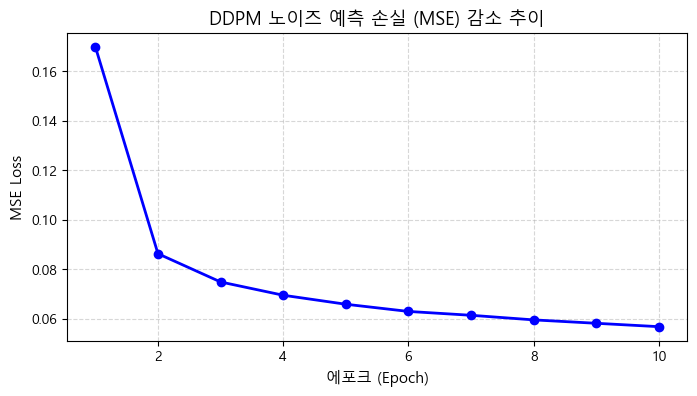

In [7]:
# Diffusion 모델 학습 실행
epochs = 10  # 실습 데모를 위해 10 에포크 진행
loss_history = []

print("Diffusion Model 학습 시작...")
for epoch in range(epochs):
    epoch_losses = []
    for step, x_batch in enumerate(train_dataset):
        loss_val = train_step(x_batch)
        epoch_losses.append(loss_val.numpy())
        
    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    print(f"에포크 {epoch+1:2d}/{epochs} | MSE Loss (Noise Prediction): {avg_loss:.5f}")

# 학습 손실 곡선 시각화
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), loss_history, "b-o", linewidth=2)
plt.title("DDPM 노이즈 예측 손실 (MSE) 감소 추이", fontsize=13)
plt.xlabel("에포크 (Epoch)", fontsize=11)
plt.ylabel("MSE Loss", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 5. 역확산 생성 샘플링 (Reverse Sampling / Generation)

이제 완전한 무작위 가우시안 노이즈 $x_T \sim \mathcal{N}(0, I)$에서 출발하여, $t = T-1$부터 $t = 0$까지 역순으로 **한 스텝씩 노이즈를 걷어내는 역확산 샘플링**을 수행합니다:
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \hat{\epsilon}_\theta(x_t, t) \right) + \sigma_t z \quad (z \sim \mathcal{N}(0, I))$$

In [8]:
@tf.function
def p_sample_step(x_t, t_val):
    # 한 스텝 노이즈 제거: x_t -> x_{t-1}
    t_tensor = tf.fill([tf.shape(x_t)[0]], t_val)
    # 모델의 노이즈 예측
    pred_noise = unet([x_t, t_tensor], training=False)
    
    beta_t = tf.gather(beta_tf, t_val)
    alpha_t = tf.gather(alpha_tf, t_val)
    sqrt_one_minus_alpha_bar_t = tf.gather(sqrt_one_minus_alpha_bar_tf, t_val)
    
    # 평균 계산
    mean = (1.0 / tf.sqrt(alpha_t)) * (x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * pred_noise)
    
    if t_val > 0:
        z = tf.random.normal(shape=tf.shape(x_t))
        sigma_t = tf.sqrt(beta_t)
        return mean + sigma_t * z
    else:
        return mean

def generate_samples(num_samples=10):
    # 순수 노이즈로부터 손글씨 숫자 생성 및 역확산 과정 기록
    # 1. 완전한 순수 가우시안 노이즈 x_T 준비
    x_current = tf.random.normal(shape=(num_samples, 28, 28, 1))
    
    intermediates = {}
    record_steps = [199, 150, 100, 50, 20, 0]
    
    # 2. t = T-1부터 0까지 역순 샘플링
    for t_step in reversed(range(timesteps)):
        x_current = p_sample_step(x_current, t_step)
        if t_step in record_steps:
            intermediates[t_step] = x_current.numpy()
            
    return x_current.numpy(), intermediates

print("순수 노이즈로부터 역확산 샘플링(생성) 진행 중...")
generated_imgs, history_steps = generate_samples(num_samples=5)
print("생성 완료!")

순수 노이즈로부터 역확산 샘플링(생성) 진행 중...
생성 완료!


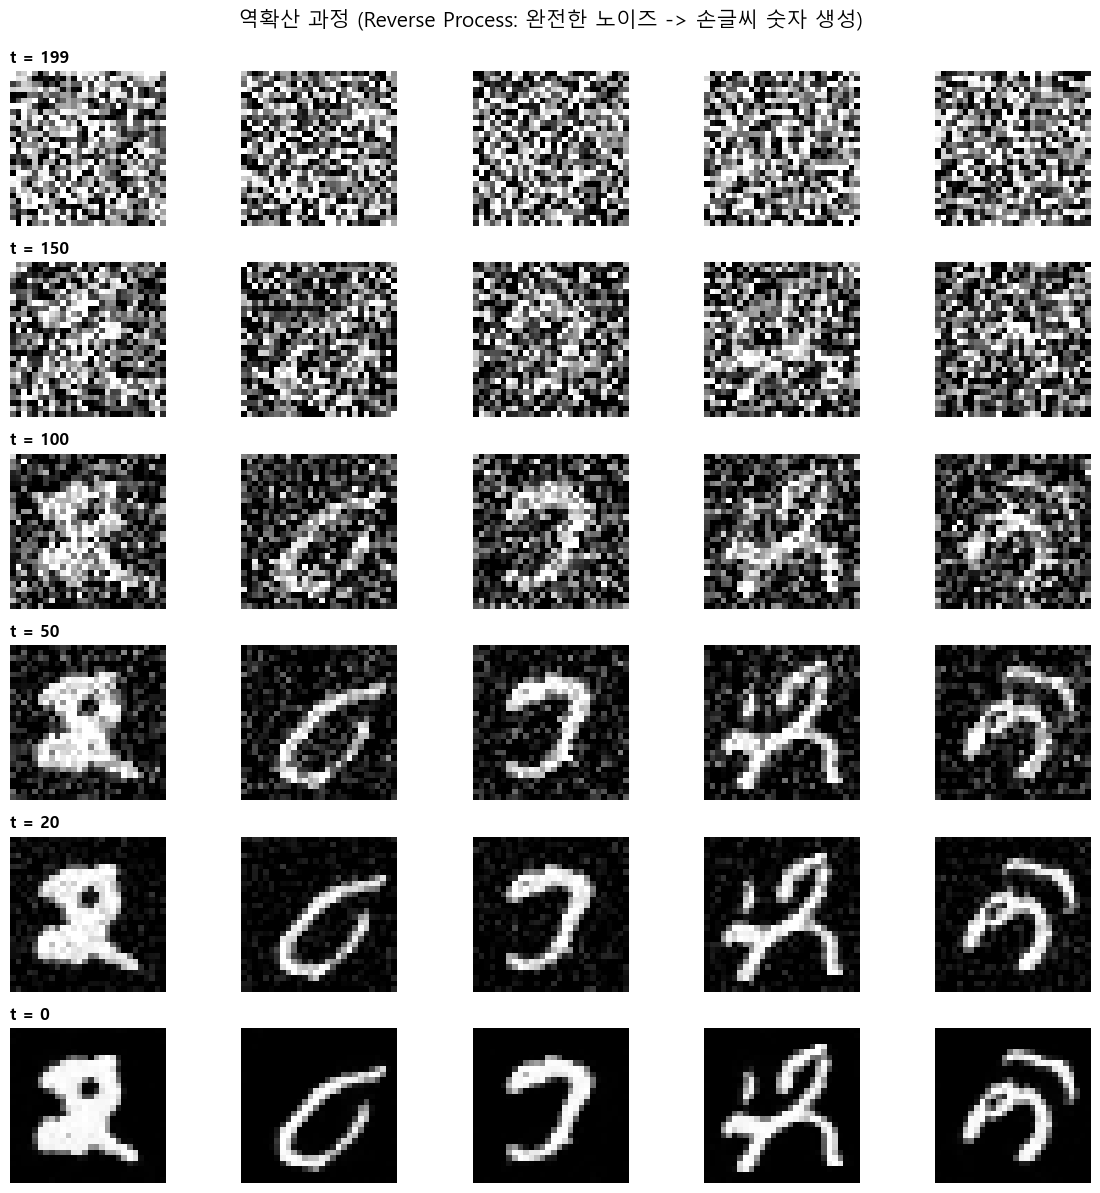

In [9]:
# 노이즈에서 숫자가 생성되는 단계별 역확산 과정 시각화
record_steps = [199, 150, 100, 50, 20, 0]

fig, axes = plt.subplots(len(history_steps), 5, figsize=(12, 12))

for row, t_step in enumerate(record_steps):
    imgs_at_t = history_steps[t_step]
    for col in range(5):
        ax = axes[row, col]
        img = (imgs_at_t[col].squeeze() + 1.0) / 2.0
        ax.imshow(np.clip(img, 0.0, 1.0), cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(f"t = {t_step}", fontsize=12, loc="left", fontweight="bold")

plt.suptitle("역확산 과정 (Reverse Process: 완전한 노이즈 -> 손글씨 숫자 생성)", fontsize=15, y=0.99)
plt.tight_layout()
plt.show()

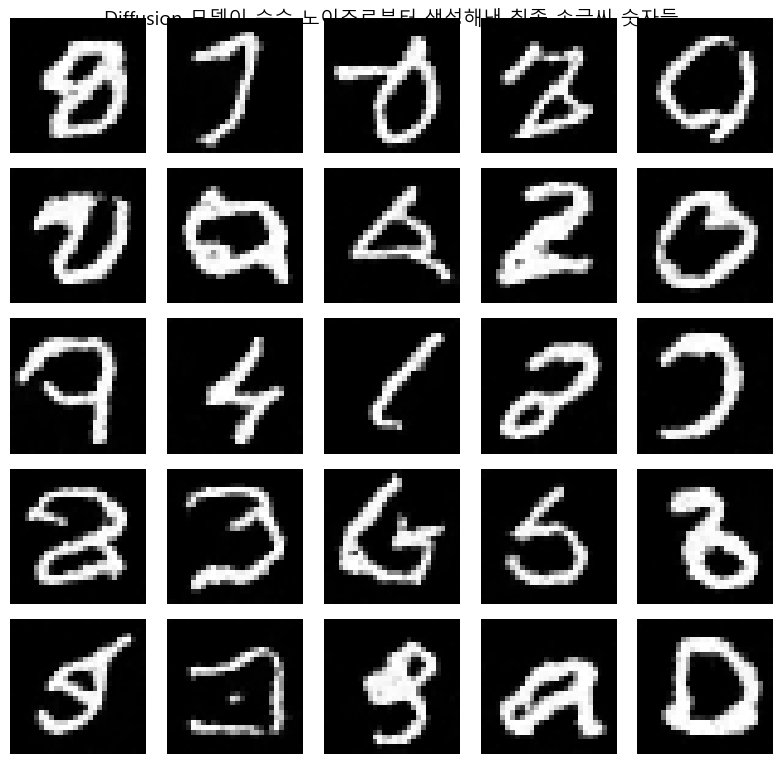

In [10]:
# 최종 생성된 25개의 손글씨 숫자 그리드 시각화
final_batch, _ = generate_samples(num_samples=25)

plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    img = (final_batch[i].squeeze() + 1.0) / 2.0
    plt.imshow(np.clip(img, 0.0, 1.0), cmap="gray")
    plt.axis("off")

plt.suptitle("Diffusion 모델이 순수 노이즈로부터 생성해낸 최종 손글씨 숫자들", fontsize=14, y=0.95)
plt.tight_layout()
plt.show()

## 6. 심층 생성 모델 4대 패밀리 총정리 및 비교

| 모델 패밀리 | 핵심 원리 | 손실 함수 | 장점 | 단점 / 실무 고려사항 |
|---|---|---|---|---|
| **Autoencoder (AE)** | 인코더-병목-디코더 | MSE / BCE | 구현 간단, 차원 축소 및 비지도 이상 탐지에 최적 | 무작위 생성 불가 (잠재 공간 불연속) |
| **Variational AE (VAE)** | 잠재 공간을 확률 분포 $\mathcal{N}(0, I)$로 정규화 | ELBO (복원오차 + KL Divergence) | 부드러운 매니폴드 보간, 확률적 샘플링 | 픽셀 평균으로 인한 흐릿한 이미지 |
| **GAN** | 생성자 vs 판별자의 적대적 경쟁 | Minimax Game / BCE | 매우 선명한 고화질 생성, 1스텝 고속 생성 | Mode Collapse, 훈련 불안정성 극심 |
| **Diffusion (DDPM)** | 노이즈 주입(Forward) 및 점진적 역노이즈 제거(Reverse) | **MSE (노이즈 예측 오차)** | **압도적인 생성 품질**, 훈련 극도로 안정적 | 다단계 반복 샘플링으로 인한 **느린 생성 속도** |

---

### 🏭 제조 AI 응용 분야
1. **불량 이미지 데이터 증강 (Defect Data Augmentation)**:
   - 양품에 비해 극도로 부족한 희소 결함(스크래치, 기포, 크랙 등) 이미지를 Diffusion으로 정밀 생성하여 불량 검사 AI 성능 극대화.
2. **센서 신호 노이즈 제거 및 초해상도 (Denoising & Super-Resolution)**:
   - 노이즈가 심한 제조 환경의 진동/초음파 센서 신호를 깨끗하게 정제.
3. **가상 공정 시뮬레이션 및 디자인 최적화**:
   - 신소재 배합이나 부품 3D 형상 설계를 생성 모델로 가상 탐색.